# E-commerce Sales Analysis

# ============================================
# 1. IMPORTS
# ============================================

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

# ============================================
# 2. DATA LOADING
# ============================================

In [ ]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

In [ ]:
print("Dataset carregado com sucesso.")
print(f"Shape: {df.shape}")

Dataset carregado com sucesso.
Shape: (9994, 21)


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# ============================================
# 3. INITIAL AUDIT
# ============================================

In [ ]:
print("\n--- Info ---")
df.info()

print("\n--- Estatísticas descritivas (numéricas) ---")
df.describe()

print("\n--- Valores únicos por coluna ---")
print(df.nunique())

print("\n--- Duplicatas ---")
print(f"Linhas duplicadas: {df.duplicated().sum()}")

print("\n--- Categorias ---")
print(df["Category"].unique())

print("\n--- Descontos únicos ---")
print(sorted(df["Discount"].unique()))


--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quant

# ============================================
# 4. DATA PREPARATION
# ============================================

In [ ]:
# Converter datas
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Features temporais
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.to_period("M")

# Dias de envio
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("\nPreparação concluída.")
print(df[["Order Date", "Ship Date", "Order Year", "Order Month", "Shipping Days"]].head())


Preparação concluída.
  Order Date  Ship Date  Order Year Order Month  Shipping Days
0 2016-11-08 2016-11-11        2016     2016-11              3
1 2016-11-08 2016-11-11        2016     2016-11              3
2 2016-06-12 2016-06-16        2016     2016-06              4
3 2015-10-11 2015-10-18        2015     2015-10              7
4 2015-10-11 2015-10-18        2015     2015-10              7


# ============================================
# 5. OVERALL SALES & PROFIT
# ============================================

In [ ]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
overall_margin = total_profit / total_sales

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Margin: {overall_margin:.2%}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Margin: 12.47%


# ============================================
# 6. CATEGORY ANALYSIS
# ============================================


--- Category Performance ---
                       Sales       Profit    Margin
Category                                           
Technology       836154.0330  145454.9481  0.173957
Office Supplies  719047.0320  122490.8008  0.170352
Furniture        741999.7953   18451.2728  0.024867


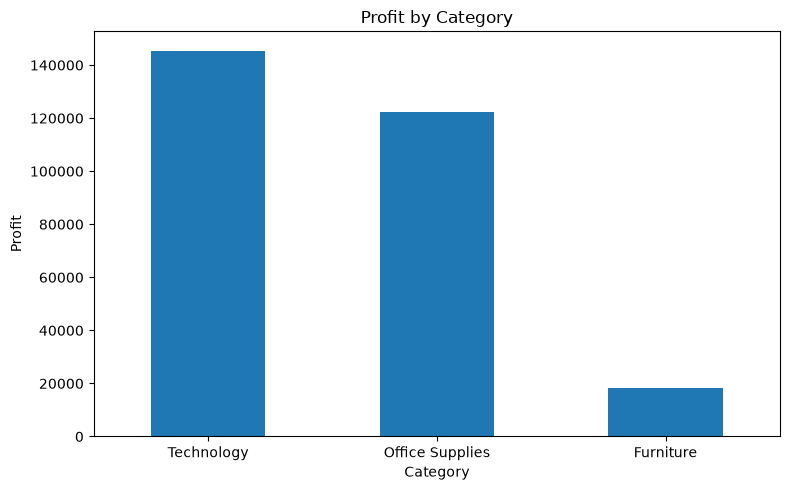

In [ ]:
category = (
    df.groupby("Category")[["Sales", "Profit"]]
    .sum()
    .assign(Margin=lambda x: x["Profit"] / x["Sales"])
    .sort_values("Profit", ascending=False)
)
print("\n--- Category Performance ---")
print(category)

# Gráfico melhorado - Lucro por Categoria
fig, ax = plt.subplots(figsize=(8, 5))
category["Profit"].plot(kind="bar", ax=ax, color=["#2ecc71", "#3498db", "#e74c3c"])
ax.set_title("Profit by Category", fontsize=14, pad=15)
ax.set_ylabel("Profit ($)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.axhline(0, color="black", linewidth=0.8)  # linha zero para referência
plt.tight_layout()
plt.show()

# ============================================
# 7. DISCOUNT ANALYSIS
# ============================================

In [ ]:
# Relação entre desconto e margem (média)
discount_analysis = (
    df.groupby("Discount")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "count")
    )
    .assign(Margin=lambda x: x["Profit"] / x["Sales"])
    .sort_index()
)
print("\n--- Discount vs Margin ---")
print(discount_analysis)

# Análise mais clara: margem média por faixa de desconto
print("\n--- Discount vs Average Margin ---")
print(discount_analysis[["Sales", "Profit", "Margin", "Orders"]].round(3))

# Gráfico: Margem de Lucro por nível de Desconto
fig, ax = plt.subplots(figsize=(10, 5))
discount_analysis["Margin"].plot(kind="bar", ax=ax, color="#e67e22")
ax.set_title("Profit Margin by Discount Level", fontsize=14, pad=15)
ax.set_ylabel("Profit Margin")
ax.set_xlabel("Discount")
ax.axhline(0, color="black", linewidth=0.8)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# ============================================
# 8. TEMPORAL ANALYSIS
# ============================================


--- Yearly Performance ---
                  Sales      Profit    Margin
Order Year                                   
2014        484247.4981  49543.9741  0.102311
2015        470532.5090  61618.6037  0.130955
2016        609205.5980  81795.1743  0.134265
2017        733215.2552  93439.2696  0.127438


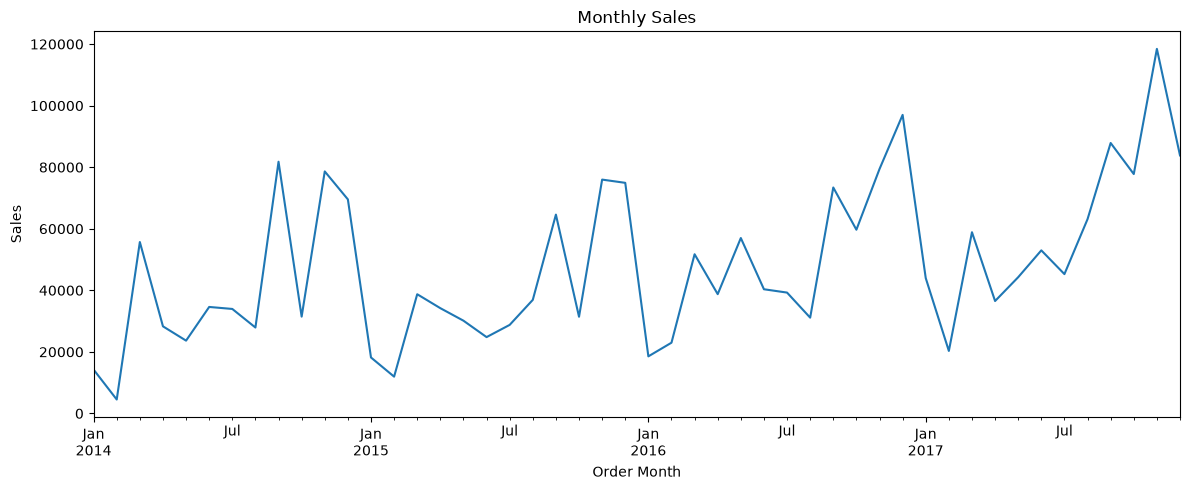

In [ ]:
yearly = (
    df.groupby("Order Year")[["Sales", "Profit"]]
    .sum()
    .assign(Margin=lambda x: x["Profit"] / x["Sales"])
)
print("\n--- Yearly Performance ---")
print(yearly)

monthly_sales = df.groupby("Order Month")["Sales"].sum()
# Gráfico melhorado - Vendas Mensais
fig, ax = plt.subplots(figsize=(12, 5))
monthly_sales.plot(kind="line", ax=ax, marker="o", linewidth=2, color="#2980b9")
ax.set_title("Monthly Sales Over Time", fontsize=14, pad=15)
ax.set_ylabel("Sales ($)")
ax.set_xlabel("Month")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 9. REGIONAL ANALYSIS
# ============================================

In [ ]:
region = (
    df.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .assign(Margin=lambda x: x["Profit"] / x["Sales"])
    .sort_values("Profit", ascending=False)
)
print("\n--- Region Performance ---")
print(region)


--- Region Performance ---
               Sales       Profit    Margin
Region                                     
West     725457.8245  108418.4489  0.149448
East     678781.2400   91522.7800  0.134834
South    391721.9050   46749.4303  0.119343
Central  501239.8908   39706.3625  0.079216


# ============================================
# 10. SUB-CATEGORY ANALYSIS
# ============================================

In [ ]:
subcategory = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .assign(Margin=lambda x: x["Profit"] / x["Sales"])
    .sort_values("Profit", ascending=False)
)
print("\n--- Sub-Category by Profit ---")
print(subcategory)

print("\n--- Sub-Category by Margin (pior para melhor) ---")
print(subcategory.sort_values("Margin"))

# Top 5 e Bottom 5 Sub-Categories por Lucro
top5 = subcategory.head(5)["Profit"]
bottom5 = subcategory.tail(5)["Profit"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top5.plot(kind="barh", ax=axes[0], color="#27ae60")
axes[0].set_title("Top 5 Sub-Categories by Profit")
axes[0].set_xlabel("Profit ($)")

bottom5.plot(kind="barh", ax=axes[1], color="#c0392b")
axes[1].set_title("Bottom 5 Sub-Categories by Profit")
axes[1].set_xlabel("Profit ($)")

plt.tight_layout()
plt.show()


--- Sub-Category by Profit ---
                    Sales      Profit    Margin
Sub-Category                                   
Copiers       149528.0300  55617.8249  0.371956
Phones        330007.0540  44515.7306  0.134893
Accessories   167380.3180  41936.6357  0.250547
Paper          78479.2060  34053.5693  0.433918
Binders       203412.7330  30221.7633  0.148574
Chairs        328449.1030  26590.1663  0.080957
Storage       223843.6080  21278.8264  0.095061
Appliances    107532.1610  18138.0054  0.168675
Furnishings    91705.1640  13059.1436  0.142404
Envelopes      16476.4020   6964.1767  0.422676
Art            27118.7920   6527.7870  0.240711
Labels         12486.3120   5546.2540  0.444187
Machines      189238.6310   3384.7569  0.017886
Fasteners       3024.2800    949.5182  0.313965
Supplies       46673.5380  -1189.0995 -0.025477
Bookcases     114879.9963  -3472.5560 -0.030228
Tables        206965.5320 -17725.4811 -0.085645

--- Sub-Category by Margin (pior para melhor) ---
     

# ============================================
# 11. KEY FINDINGS
# ============================================

In [ ]:
print("\n" + "="*50)
print("KEY FINDINGS")
print("="*50)
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Margin: {overall_margin:.2%}")
print(f"\nBest Category (Profit): {category.index[0]}")
print(f"Worst Sub-Category (Margin): {subcategory.sort_values('Margin').index[0]}")
print(f"Best Region: {region.index[0]}")


KEY FINDINGS
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Margin: 12.47%

Best Category (Profit): Technology
Worst Sub-Category (Margin): Tables
Best Region: West
